## Particle size distribution and viscosity calculations

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use given style
plt.style.use("james2026lock.mplstyle")

# import PSD data
data = pd.read_csv("../../data/metadata/clay_psd.csv", sep=",")
data = data[data["ultrasound_time"] == 0]  # only select the non-vibrated data

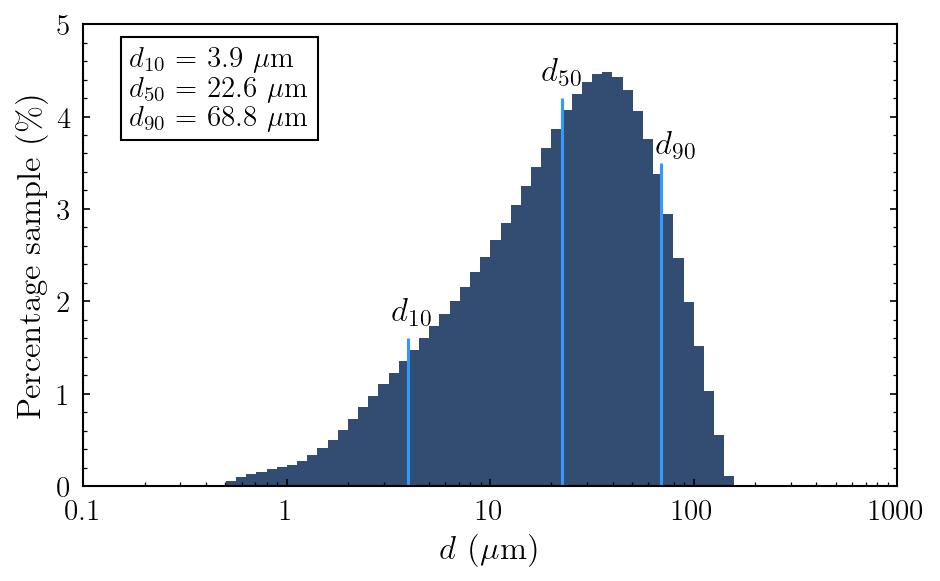

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))

# --- Bin geometry ---
edges = data["diameter_micron"].to_numpy()
x_center = (edges[1:] + edges[:-1]) / 2
x_widths = edges[1:] - edges[:-1]
percent = data["percent"].iloc[1:].to_numpy()

# --- Cumulative statistics ---
cumsum = np.cumsum(percent)
d10 = np.interp(10, cumsum, x_center)
d50 = np.interp(50, cumsum, x_center)
d90 = np.interp(90, cumsum, x_center)

# --- Plot bars ---
ax.bar(x_center, percent, width=x_widths, alpha=0.8, color="#001F4D")

# --- Percentile lines and labels ---
vline_xs = [d10, d50, d90]
vline_tops = [1.6, 4.2, 3.5]
ax.vlines(vline_xs, 0, vline_tops, color="#3399FF")

label_positions = [
    (3.3, 1.8, r"$d_{10}$"),
    (18, 4.4, r"$d_{50}$"),
    (65, 3.6, r"$d_{90}$"),
]
for x, y, label in label_positions:
    ax.text(x, y, label, fontsize=16)

# --- Stats text box ---
stats_text = "\n".join(
    [
        rf"$d_{{10}}$ = {d10:.1f} $\mu$m",
        rf"$d_{{50}}$ = {d50:.1f} $\mu$m",
        rf"$d_{{90}}$ = {d90:.1f} $\mu$m",
    ]
)

legend_box = dict(
    facecolor="white",
    edgecolor="black",
    alpha=1,
    boxstyle="round" if plt.rcParams["legend.fancybox"] else "square",
)
ax.text(0.17, 3.9, stats_text, fontsize=14, bbox=legend_box)

# --- Axes formatting ---
ax.set_xlim([0.1, 1000])
ax.set_ylim([0, 5])
ax.set_xscale("log")
ax.set_xticks([0.1, 1, 10, 100, 1000])
ax.set_xticklabels(["0.1", "1", "10", "100", "1000"])
ax.set_xlabel(r"$d\ (\mu\mathrm{m})$")
ax.set_ylabel(r"Percentage sample (\%)")
ax.grid()

# --- Save and show ---
plt.savefig("../figures/figure_S2.png", dpi=300, bbox_inches="tight")
plt.show()

## Viscosity models

We compare four models of increasing complexity. All return the
**relative viscosity** $\mu_r$ = $\mu$ _suspension / $\mu$ _water.
Multiply by `ETA_WATER` to get absolute viscosity in mPa·s.

---

### Model 1 — Einstein (1906)
The exact analytical result for rigid, non-interacting spheres at infinite dilution:
$$\mu_r = 1 + 2.5\,\phi$$
Valid strictly for φ → 0. No fitting parameters. This is the hard lower bound.

---

### Model 2 — Intrinsic viscosity
Replaces Einstein’s 2.5 with a fitted **intrinsic viscosity [η]**:
$$\mu_r = 1 + [\eta]\,\phi$$
For spheres [η] = 2.5; for platelets like bentonite it is much higher
(literature range ~10–40 for montmorillonite) because flat particles
disturb more flow than a sphere of the same volume.

---

### Model 3 — Virial (second-order)
Adds a φ² term to capture particle–particle hydrodynamic interactions:
$$\mu_r = 1 + [\eta]\,\phi + k_H\,[\eta]^2\,\phi^2$$
k_H is the **Huggins coefficient** (~0.5–1.0 for well-dispersed particles).
At these concentrations the φ² correction is small but non-negligible at 40 g/L.

---

### Model 4 — Krieger–Dougherty with effective volume fraction
At higher concentrations particles start to feel each other and viscosity
diverges as φ approaches a maximum packing fraction φ$_m$:
$$\mu_r = \left(1 - \frac{\phi_{\rm eff}}{\phi_m}\right)^{-[\eta]\,\phi_m}$$
where φ$_{\text{eff}}$ = λ·φ inflates the bare volume fraction to account for the
hydration layer and the extra excluded volume around each platelet.
We estimate λ from the d32 of the PSD using:
$$λ = 1 + A\,\frac{d_{\rm ref}}{d_{32}}$$
Smaller particles → higher surface-area-to-volume ratio → larger λ.
This model reduces to the intrinsic-viscosity model at low φ.

In [3]:
# ── Model parameters ──────────────────────────────────────────────────────
# convert from g/L to volume fraction phi using the wetted density of the clay
RHO_CLAY = 2277.0  # kg/m3, wetted density (your calibrated value)
MU_WATER = 1.002  # mPa.s, freshwater viscosity at 20 degC

conc_g_L = np.array([1.0, 2.5, 5.0, 10.0, 20.0, 30.0, 40.0])  # g/L
phi = conc_g_L / RHO_CLAY  # volume fraction

print(f"{'c (g/L)':>10}  {'phi':>10}  {'phi %':>8}")
print("-" * 34)
for c, p in zip(conc_g_L, phi):
    print(f"{c:>10.1f}  {p:>10.5f}  {p*100:>8.4f}")
print(
    f"\nMax phi = {phi.max():.4f}  -- all concentrations are in the dilute regime (phi << 1)"
)

# Percentile diameters straight from the cumulative volume sum
d = data["diameter_micron"].values  # bin centre diameters (um)
vol = data["percent"].values  # volume % in each bin (sums to 100)
cumvol = np.cumsum(vol)  # cumulative volume %, runs 0 -> 100
d10 = np.interp(10.0, cumvol, d)
d50 = np.interp(50.0, cumvol, d)
d90 = np.interp(90.0, cumvol, d)

# Sauter mean (d32) and De Brouckere mean (d43) from volume-weighted moments
# For a volume-weighted distribution: d32 = 1 / mean(1/d),  d43 = mean(d)
d32 = np.nansum(vol) / np.nansum(vol / d)  # = 1 / <1/d>_volume
d43 = np.nansum(vol * d) / np.nansum(vol)  # = <d>_volume

# [eta] intrinsic viscosity: 2.5 for spheres; for bentonite platelets we
# use 25 as a central estimate (mid-range for montmorillonite literature).
# Change this to explore sensitivity.
intrinsic_visc = 25

# Huggins coefficient for the virial model
k_H = 0.7

# Maximum packing fraction for Krieger-Dougherty
phi_m = 0.6  # typical random-loose packing

# Effective-volume inflation: lambda = 1 + A * (d_ref / d32)
# d_ref = 1 um is a reference size; A = 2 is a mid-range choice.
A = 2.0
d_ref = 1.0  # um
lam = 1.0 + A * (d_ref / d32)

print(f"d32 used for lambda calculation: {d32:.2f} um")
print(f"Effective-volume inflation factor lambda = {lam:.3f}")
print(
    f"  -> phi_eff = {lam:.3f} * phi  (particles occupy {lam:.1f}x their bare volume)"
)
print()
print(f"Intrinsic viscosity [eta]  = {intrinsic_visc}")
print(f"Huggins coefficient k_H    = {k_H}")
print(f"Max packing fraction phi_m = {phi_m}")

   c (g/L)         phi     phi %
----------------------------------
       1.0     0.00044    0.0439
       2.5     0.00110    0.1098
       5.0     0.00220    0.2196
      10.0     0.00439    0.4392
      20.0     0.00878    0.8783
      30.0     0.01318    1.3175
      40.0     0.01757    1.7567

Max phi = 0.0176  -- all concentrations are in the dilute regime (phi << 1)
d32 used for lambda calculation: 10.49 um
Effective-volume inflation factor lambda = 1.191
  -> phi_eff = 1.191 * phi  (particles occupy 1.2x their bare volume)

Intrinsic viscosity [eta]  = 25
Huggins coefficient k_H    = 0.7
Max packing fraction phi_m = 0.6


In [4]:
# ── Compute viscosities at each concentration ─────────────────────────────

# Model 1: Einstein
mu_r_einstein = 1 + 2.5 * phi

# Model 2: Intrinsic viscosity (linear in phi)
mu_r_intrinsic = 1 + intrinsic_visc * phi

# Model 3: Virial / Huggins expansion (quadratic in phi)
mu_r_virial = 1 + intrinsic_visc * phi + k_H * intrinsic_visc**2 * phi**2

# Model 4: Krieger-Dougherty with inflated phi
phi_eff = lam * phi
phi_eff = np.minimum(phi_eff, 0.999 * phi_m)  # prevent division by zero
mu_r_krieger = (1 - phi_eff / phi_m) ** (-intrinsic_visc * phi_m)

# Convert to absolute viscosity (mPa.s)
mu_einstein = mu_r_einstein * MU_WATER
mu_intrinsic = mu_r_intrinsic * MU_WATER
mu_virial = mu_r_virial * MU_WATER
mu_krieger = mu_r_krieger * MU_WATER

# Print table
print(f"Water viscosity = {MU_WATER} mPa.s at 20 degC")
print()
print(
    f"{'c (g/L)':>8}  {'phi':>8}  {'Einstein':>10}  {'Intrinsic':>10}  {'Virial':>10}  {'K-D':>10}  (mPa.s)"
)
print("-" * 68)
for i in range(len(conc_g_L)):
    print(
        f"{conc_g_L[i]:>8.1f}  {phi[i]:>8.5f}"
        f"  {mu_einstein[i]:>10.4f}"
        f"  {mu_intrinsic[i]:>10.4f}"
        f"  {mu_virial[i]:>10.4f}"
        f"  {mu_krieger[i]:>10.4f}"
    )

Water viscosity = 1.002 mPa.s at 20 degC

 c (g/L)       phi    Einstein   Intrinsic      Virial         K-D  (mPa.s)
--------------------------------------------------------------------
     1.0   0.00044      1.0031      1.0130      1.0131      1.0152
     2.5   0.00110      1.0048      1.0295      1.0300      1.0353
     5.0   0.00220      1.0075      1.0570      1.0591      1.0698
    10.0   0.00439      1.0130      1.1120      1.1205      1.1426
    20.0   0.00878      1.0240      1.2220      1.2558      1.3044
    30.0   0.01318      1.0350      1.3320      1.4081      1.4909
    40.0   0.01757      1.0460      1.4421      1.5773      1.7061


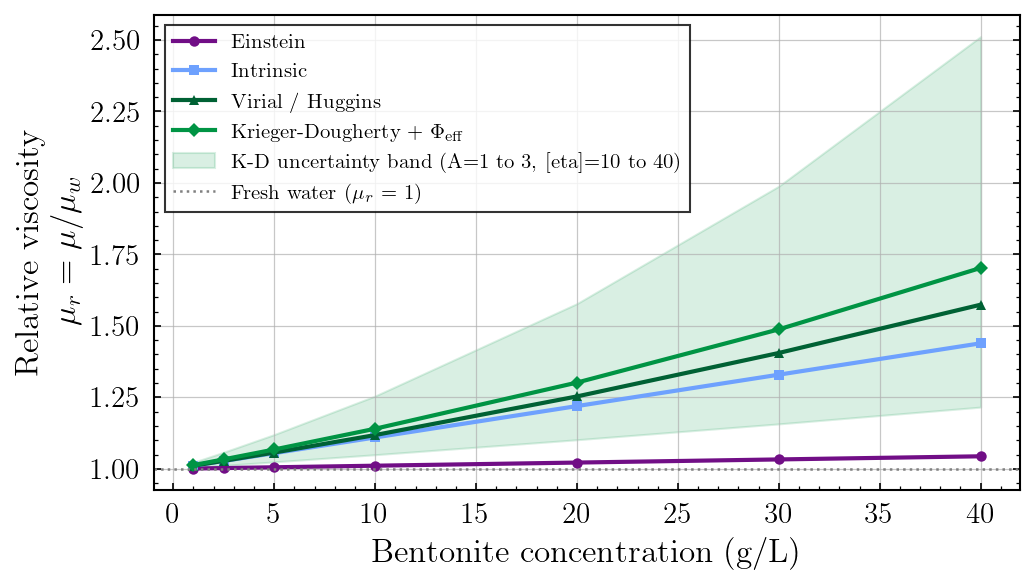

In [5]:
# Uncertainty band: vary [eta] from 10 to 40, keep everything else fixed
eta_lo = (1 + 10.0 * phi) * MU_WATER  # intrinsic low
lam_hi = 1.0 + 3.0 * (d_ref / d32)  # A=3 upper
phi_eff_hi = np.minimum(lam_hi * phi, 0.999 * phi_m)
eta_kd_hi = (1 - phi_eff_hi / phi_m) ** (-40.0 * phi_m) * MU_WATER  # KD upper bound
eta_kd_lo = (
    1 - np.minimum((1 + 1.0 * (d_ref / d32)) * phi, 0.999 * phi_m) / phi_m
) ** (
    -10.0 * phi_m
) * MU_WATER  # kd lower bound

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(conc_g_L, mu_r_einstein, "C0-o", linewidth=2, markersize=5, label="Einstein")
ax.plot(
    conc_g_L,
    mu_r_intrinsic,
    "C1-s",
    linewidth=2,
    markersize=5,
    label="Intrinsic",
)
ax.plot(
    conc_g_L, mu_r_virial, "C2-^", linewidth=2, markersize=5, label="Virial / Huggins"
)
ax.plot(
    conc_g_L,
    mu_r_krieger,
    "C3-D",
    linewidth=2,
    markersize=5,
    label="Krieger-Dougherty + $\\Phi_{\\mathrm{eff}}$",
)
ax.fill_between(
    conc_g_L,
    eta_kd_lo / MU_WATER,
    eta_kd_hi / MU_WATER,
    color="C3",
    alpha=0.15,
    label="K-D uncertainty band (A=1 to 3, [eta]=10 to 40)",
)

ax.axhline(
    1.0, color="grey", linewidth=1.2, linestyle=":", label="Fresh water ($\\mu_r$ = 1)"
)

ax.set_xlabel("Bentonite concentration (g/L)")
ax.set_ylabel("Relative viscosity \n $\\mu_r = \\mu / \\mu_{w}$")
ax.legend(fontsize=10, loc="upper left")

plt.tight_layout()
plt.savefig("../figures/figure_S4.png", dpi=300, bbox_inches="tight")
plt.show()